# Committor analysis

In [1]:
import numpy as np
from ase.io import read
from ase.md.bussi import Bussi
from ase import units
from franken.calculators import FrankenCalculator
import plumed
import os
import pandas as pd

from asetps import CommittorAnalysis

In [2]:
os.chdir("..")

import utils.figures as figures
import utils.helpers as helpers

os.chdir("SN2")

## Load sampling

In [3]:
shooting_frames = read("SAMPLING_TS/sampling.xyz", ":")

## Define states

In [ ]:
def colvar_fn(at, cvs=None):
    at.info["d1"] = float(at.get_distance(0, 1))
    at.info["d2"] = float(at.get_distance(0, 5))

state_A = {"d1": [">1.6", "<2.0"],
           "d2": [">2.5"]}

state_B = {"d1": [">2.5"],
           "d2": [">1.6", "<2.0"]}

## Committor simulations

In [ ]:
T = 300 # K
timestep = 0.5 # fs
taut = 100 # fs

calc = FrankenCalculator("FRANKEN/results/run_260521_212030_3e0f67c3/best_ckpt.pt")

dyn_cls = Bussi
dyn_kwargs = {'taut': taut * units.fs,
              'temperature_K' : T}

In [ ]:
committor = CommittorAnalysis(
    colvar_fn=colvar_fn,
    state_A=state_A,
    state_B=state_B,
    nsteps=1000,
    ntrials=100,
    timestep=timestep * units.fs,
    temperature_K=T,
    dyn_cls=dyn_cls,
    dyn_kwargs=dyn_kwargs,
    calc=calc,
    check_commit_interval=10,
)

results = committor.run(shooting_frames)

In [ ]:
q = np.array([a.info["committor.p_B"] for a in shooting_frames])
np.savetxt("SAMPLING/COMMITTOR", q, fmt="%9.6f", header="FIELDS q", comments="#! ")

# Analysis

In [4]:
q = np.loadtxt("SAMPLING_TS/COMMITTOR")

In [6]:
data = pd.read_csv("SAMPLING_TS/COLVAR")

figures.chemiscope(
    shooting_frames,
    q,
    data["d1"].to_numpy().T,
    data["d2"].to_numpy().T,
    save_directory="SAMPLING_TS",
    save_name="committor",
)

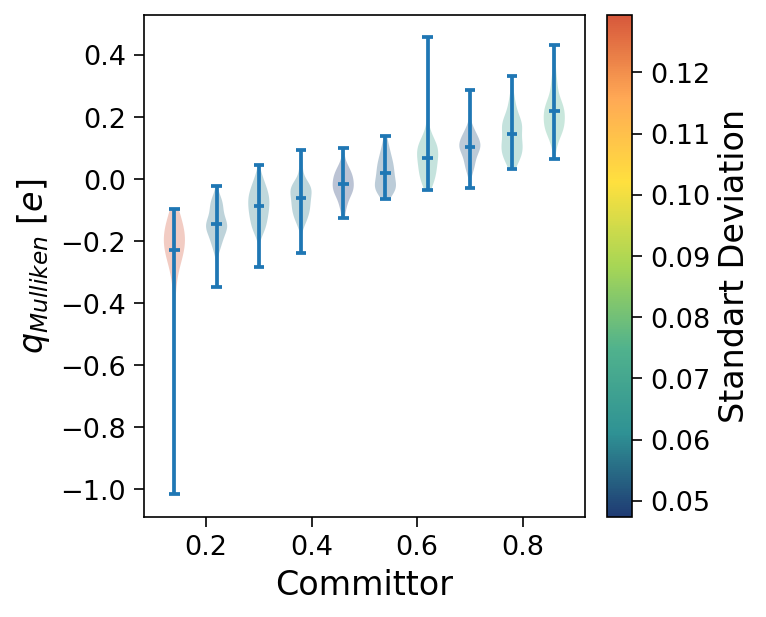

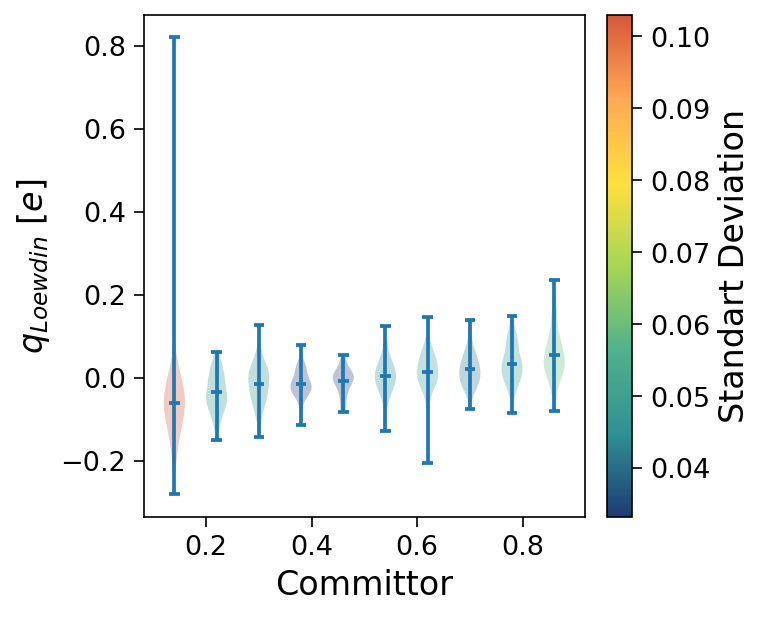

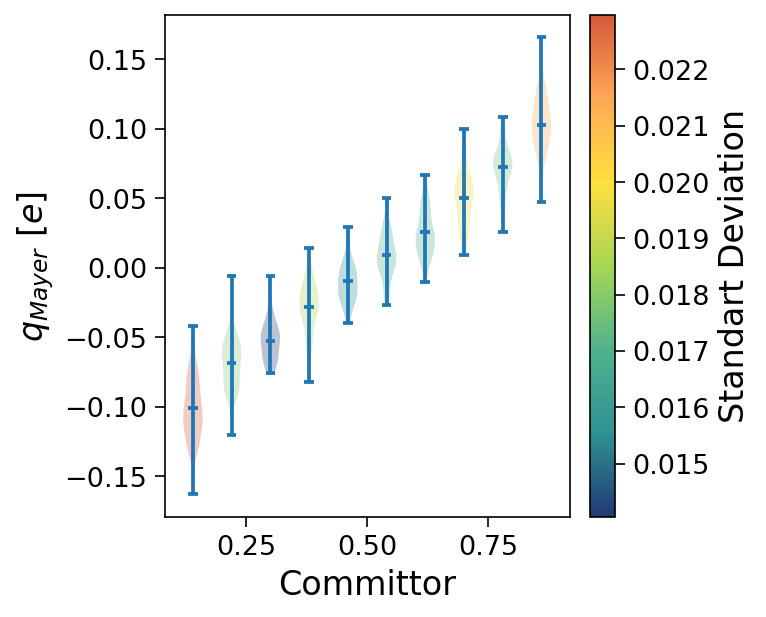

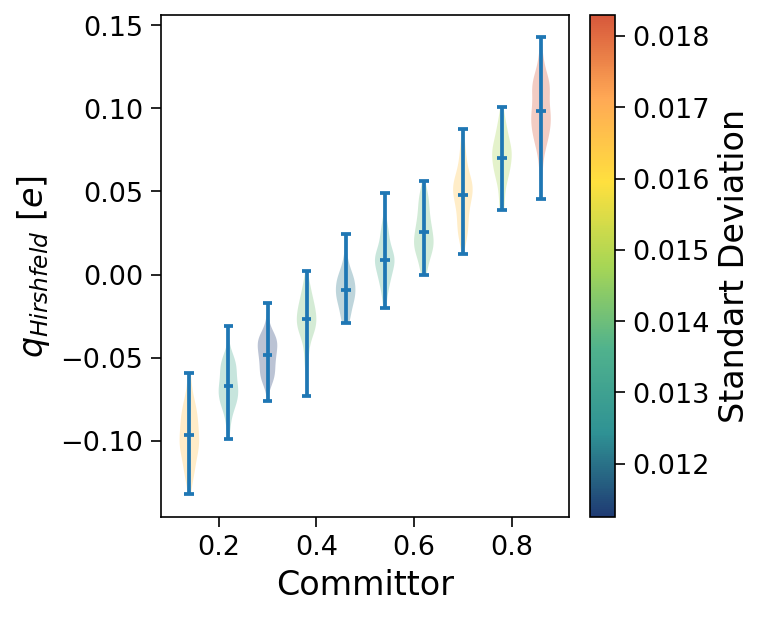

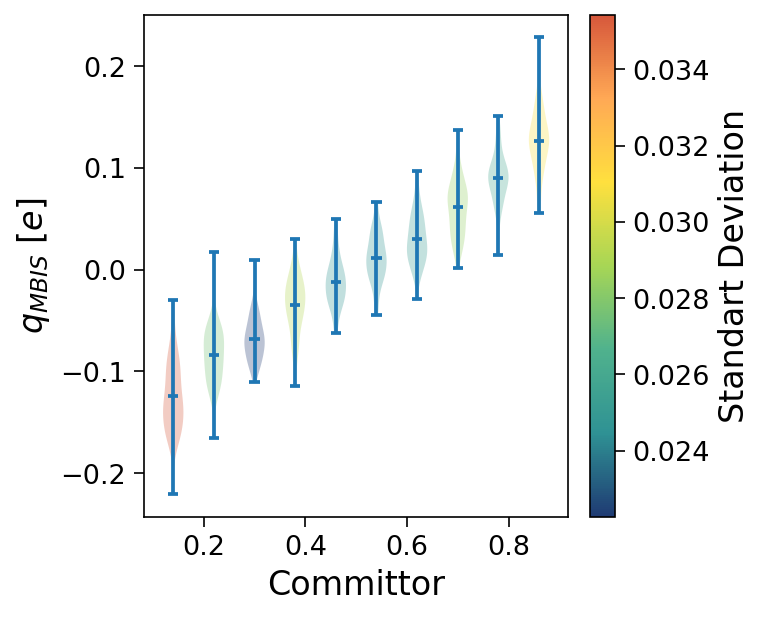

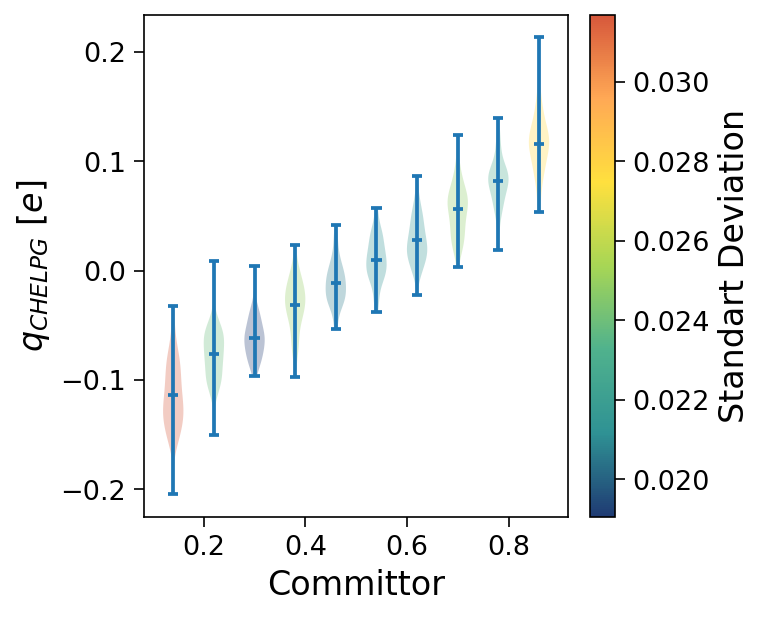

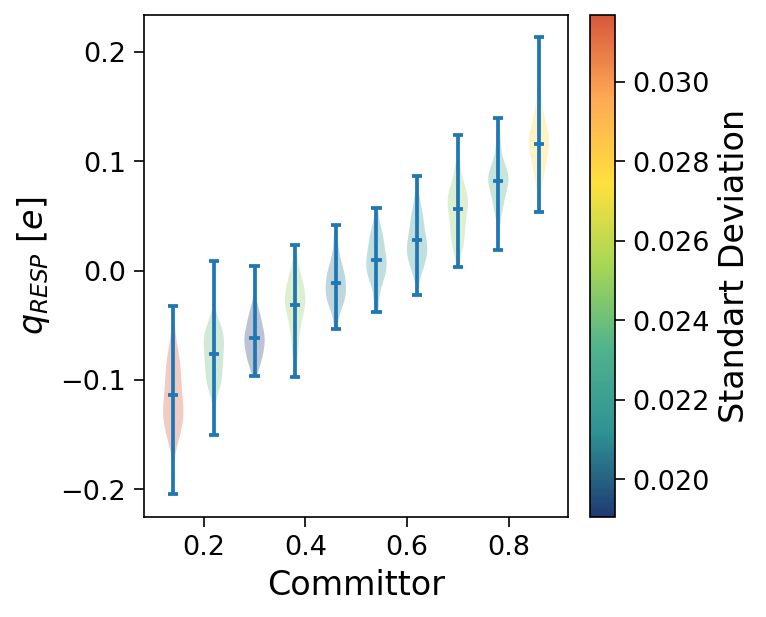

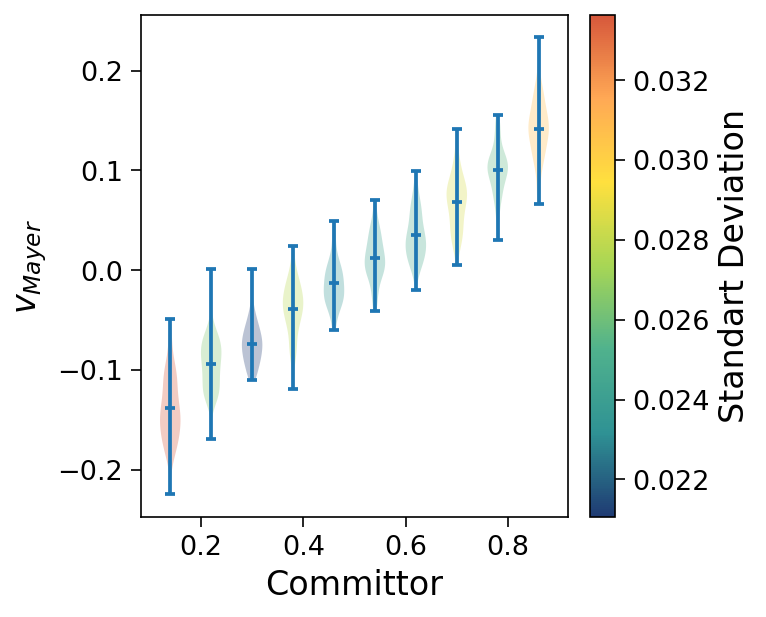

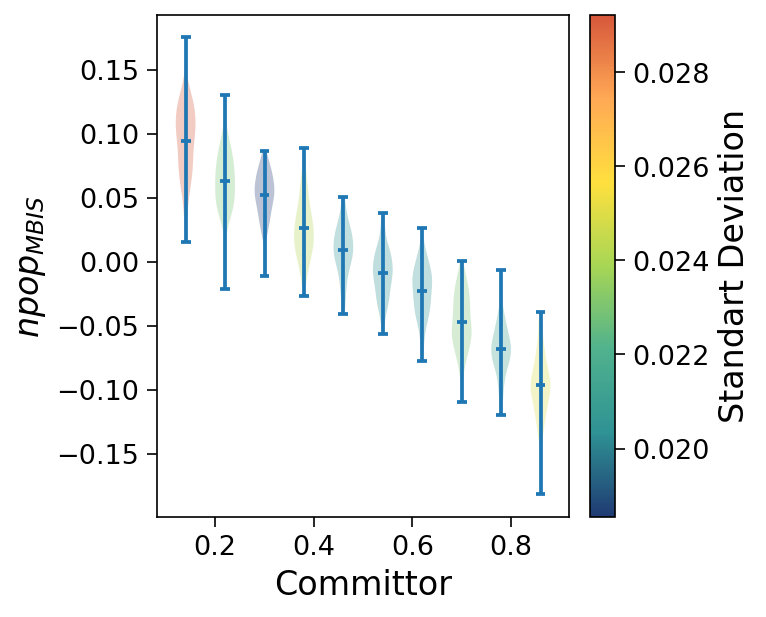

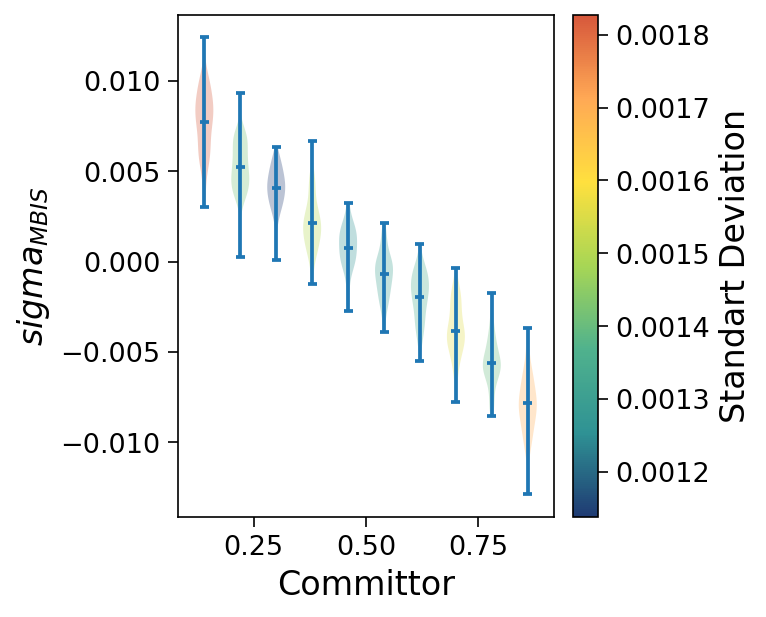

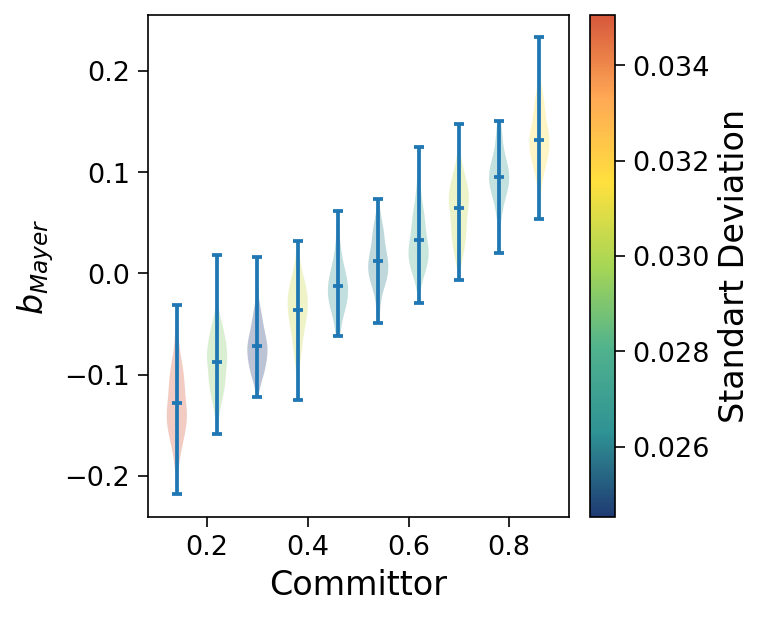

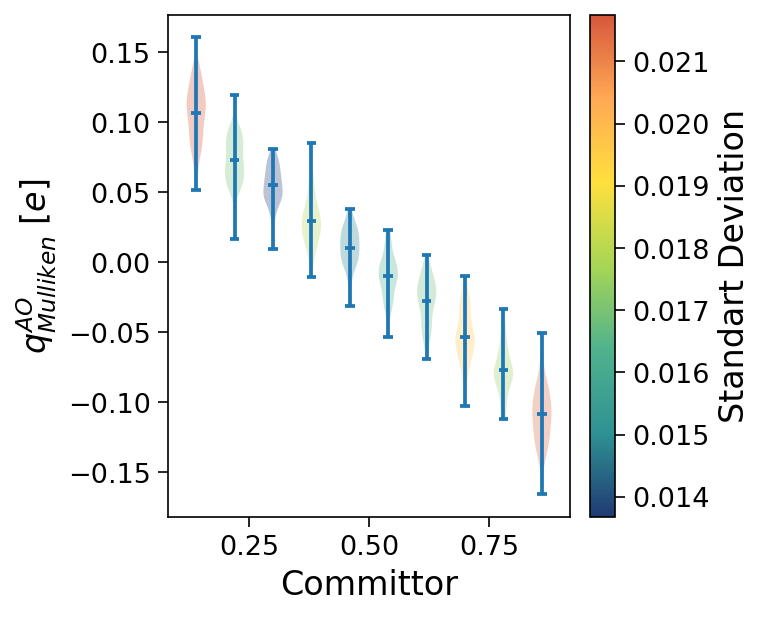

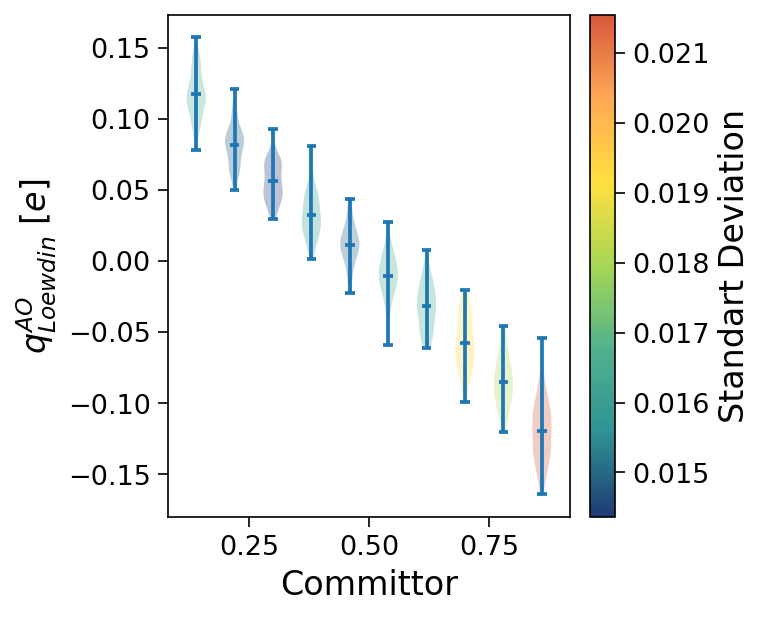

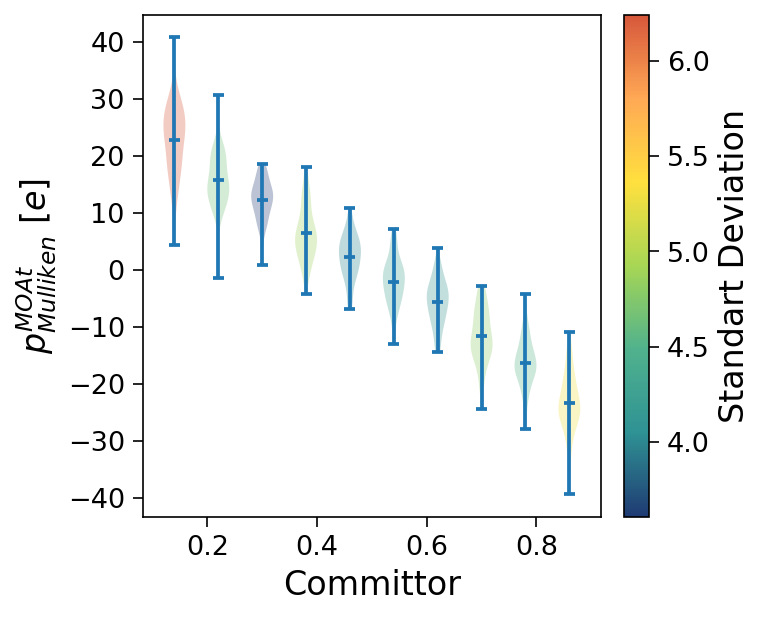

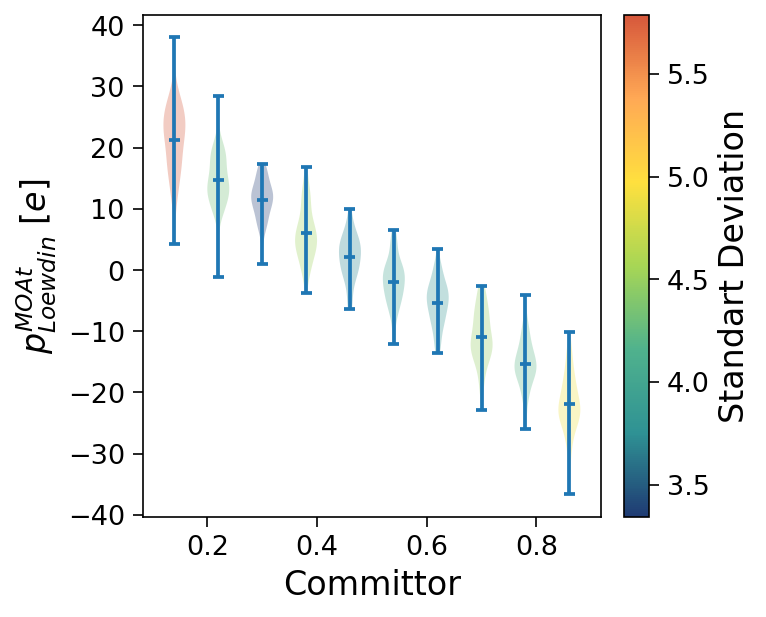

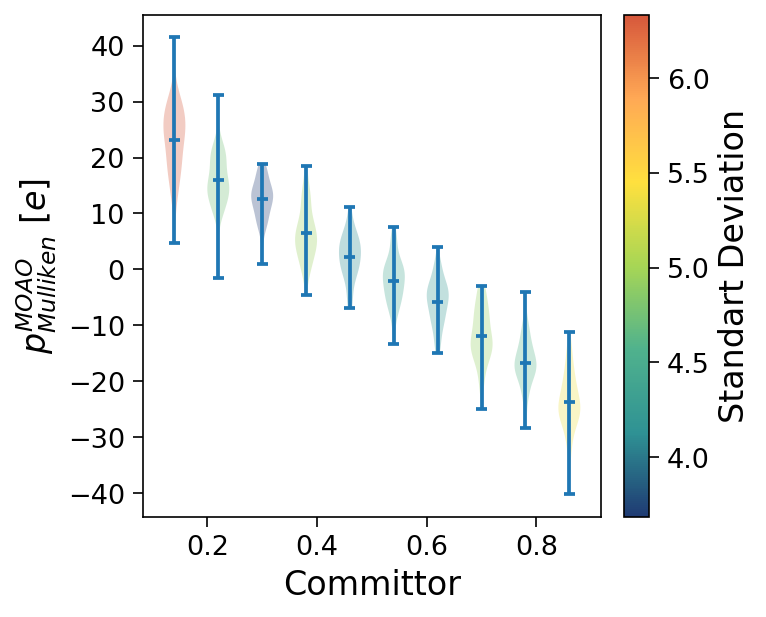

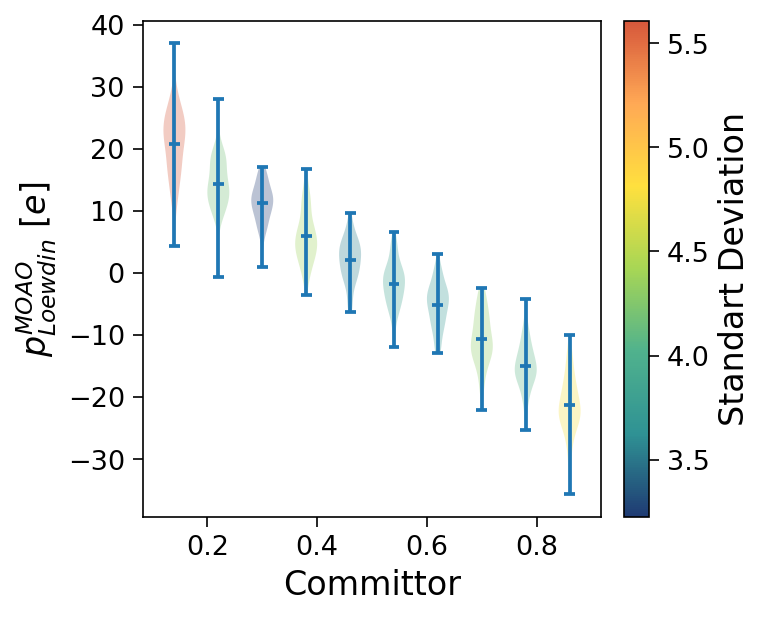

In [7]:
chemcvs = pd.read_csv("SAMPLING_TS/CHEMCV")

labels = {
    "q_Mulliken": r"$q_{Mulliken}\ [e]$",
    "q_Loewdin": r"$q_{Loewdin}\ [e]$",
    "q_Mayer": r"$q_{Mayer}\ [e]$",
    "q_Hirshfeld": r"$q_{Hirshfeld}\ [e]$",
    "q_MBIS": r"$q_{MBIS}\ [e]$",
    "q_CHELPG": r"$q_{CHELPG}\ [e]$",
    "q_RESP": r"$q_{RESP}\ [e]$",
    "v_Mayer": r"$v_{Mayer}$",
    "npop_MBIS": r"$npop_{MBIS}$",
    "sigma_MBIS": r"$sigma_{MBIS}$",
    "b_Mayer": r"$b_{Mayer}$",
    "q_AO_Mulliken": r"$q^{AO}_{Mulliken}\ [e]$",
    "q_AO_Loewdin": r"$q^{AO}_{Loewdin}\ [e]$",
    "p_MOAt_Mulliken": r"$p^{MOAt}_{Mulliken}\ [e]$",
    "p_MOAt_Loewdin": r"$p^{MOAt}_{Loewdin}\ [e]$",
    "p_MOAO_Mulliken": r"$p^{MOAO}_{Mulliken}\ [e]$",
    "p_MOAO_Loewdin": r"$p^{MOAO}_{Loewdin}\ [e]$",
}

for key, chemcv in chemcvs.items():
    bins, dataset = helpers.bin_2D(
        q,
        chemcv.to_numpy().T,
        nb_bins=10,
        bounds=(0.1, 0.9),
    )
    err = np.array([np.std(bin_dataset) for bin_dataset in dataset])
    fig = figures.violin_correlation(
        bins,
        dataset,
        xlabel="Committor",
        ylabel=labels[key],
        color=err,
        color_label=r"Standart Deviation"
    )
    fig.savefig(f"SAMPLING_TS/violin_q/{key}.svg")

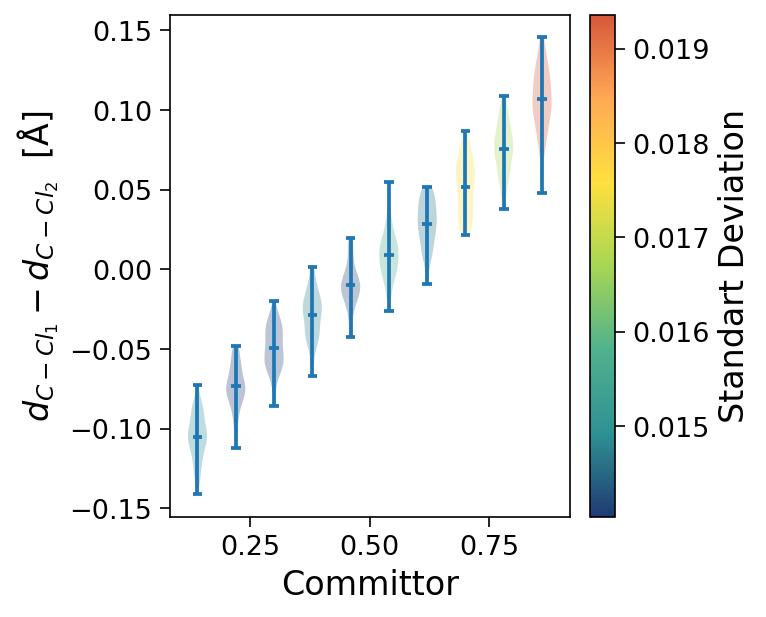

In [9]:
geomcv = pd.read_csv("SAMPLING_TS/COLVAR")["dd"].to_numpy().T

bins, dataset = helpers.bin_2D(
    q,
    geomcv,
    nb_bins=10,
    bounds=(0.1, 0.9),
)
err = np.array([np.std(bin_dataset) for bin_dataset in dataset])
fig = figures.violin_correlation(
    bins,
    dataset,
    xlabel="Committor",
    ylabel=r"$d_{C-Cl_1} - d_{C-Cl_2}$  [Å]",
    color=err,
    color_label=r"Standart Deviation"
)
fig.savefig(f"SAMPLING_TS/violin_q/geomcv.svg")